Let's sample and perform an 8-point DFT on a continuous input signal containing components at 1 kHz and 2 kHz and sample it every t_s = 1 / f_s. f_s =  8 kHz.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pprint

Generate a sequence of time points for signal processing.

In [2]:
# samp_rate is the number of samples per second (for instance value 8000 means 8 kHz).
f_s = 8000

# N - number of elements (samples) for DFT
# n - the indice for the input samples ( n = N - 1 )
# m - the indice for the output samples ( m = N - 1 )
N = 8

# Time interval between each sample
t_s = 1.0 / f_s

# t is an array of time points. It starts at 0 seconds, ends just before 1 second, incrementing by t_s with each step.
t = np.arange ( 0 , N * t_s , t_s )
print ( f"{t_s=}" )
print ( f"{t=}" )

t_s=0.000125
t=array([0.      , 0.000125, 0.00025 , 0.000375, 0.0005  , 0.000625,
       0.00075 , 0.000875])


Generate 2 sine waves with frequencies 1 kHz and 2 kHz shifted in phase by 135° (3π/4 radians) relative to the 1 kHz sinewave.

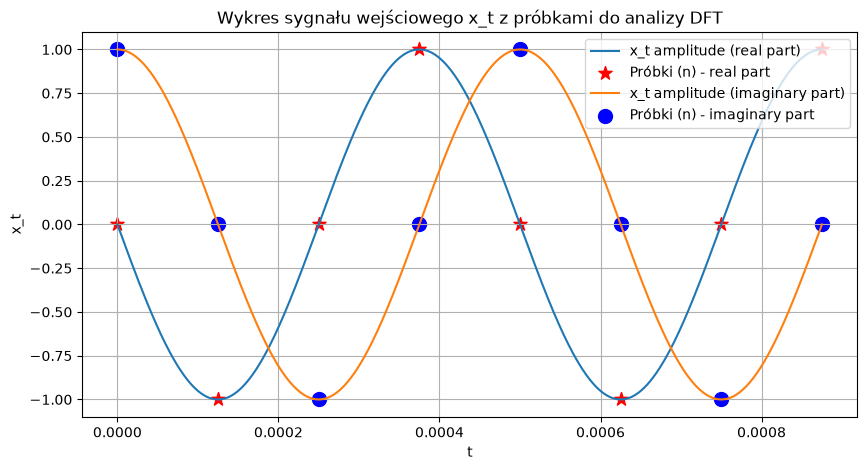

In [14]:
f_c = 2000.0
x_t_phi = 0.5 * np.pi  # Phase shift of the signal in radians
# Sygnał zespolony w dziedzinie czasu, reprezentowany jako kombinacja funkcji sinusoidalnych
x_t = np.cos ( 2 * np.pi * f_c * t + x_t_phi ) + 1j * np.sin ( 2 * np.pi * f_c * t + x_t_phi )

plot_count = 1000 # 1000 punktów na optrzeby rysunku
t_plot = np.linspace ( 0 , ( N - 1 ) * t_s , num = plot_count )  # 1000 punktów w tym zakresie
x_t_plot = np.cos ( 2 * np.pi * f_c * t_plot + x_t_phi ) + 1j * np.sin ( 2 * np.pi * f_c * t_plot + x_t_phi )
plt.figure ( figsize = ( 10 , 5 ) )
plt.title ( 'Wykres sygnału wejściowego x_t z próbkami do analizy DFT' )
plt.plot ( t_plot , x_t_plot.real , label = 'x_t amplitude (real part)' )
plt.scatter ( t , x_t.real , color = 'red' , marker = '*' , s = 100 , label = 'Próbki (n) - real part' )
plt.plot ( t_plot , x_t_plot.imag , label = 'x_t amplitude (imaginary part)' )
plt.scatter ( t , x_t.imag , color = 'blue' , marker = 'o' , s = 100 , label = 'Próbki (n) - imaginary part' )
plt.xlabel ( 't' )
plt.ylabel ( 'x_t' )
plt.legend ()
plt.grid ( True )
plt.show ()

Define dft ( x ) function which will calculate the DFT of the signal x ( t ) and takes in arguments:
x_t - input 1 dimensional real-valued signal.
N   - number of elements
f_s - sampling rate

In [ ]:
def dft ( x_t , f_s , N ) :
    """ Bezpośrednia, matematyczna implementacja 'The forward complex DFT' na podstawie równania
    w rozdziale 31-5 z książki https://drive.google.com/file/d/1WGczHNkIarIb6jNJJu-Hux9K7WrOd1qL.
    
    Parametry:
    x_t: lista/krotka próbek sygnału w czasie (liczby zespolone lub rzeczywiste)
    f_s: częstotliwość próbkowania w Hz (używana do wyznaczenia osi fizycznej w Hz)
    N: liczba próbek do analizy
    
    Zwraca:
    f: lista wyliczonych fizycznych częstotliwości [Hz] dla każdego prążka
    X: lista zespolonych prążków widma dla kolejnych indeksów k
    """
    result = np.zeros ( ( N , 3 ) ) # 3 kolumny: częstotliwość (liczba zespolona), amplituda (liczby rzeczywista), faza
    if N <= 0 :
        raise ValueError ( "Liczba próbek N musi być większa od zera" )
    if x_t is None or len(x_t) != N :
        raise ValueError ( "x_t musi być tablicą o długości N" )
    if f_s <= 0 :
        raise ValueError ( "Częstotliwość próbkowania f_s musi być większa od zera" )
    # Oblicz DFT dla każdej częstotliwości m sygnału zespolonego x_t
    X = []  # Lista na wyniki zespolone widma
    f = []  # Lista na oś częstotliwości w Hz
    
    # Zewnętrzna pętla dla każdego prążka częstotliwości 'k' (od 0 do N-1)
    for k in range(N):
        
        # Zmienna akumulująca sumę (odpowiednik matematycznego znaku Sigma)
        suma = 0j
        
        # Wewnętrzna pętla dla wszystkich próbek w czasie 'n' (od 0 do N-1)
        for n in range(N):
            
            # Człon wykładniczy z Równania 31-5: e^(-j * 2 * pi * k * n / N)
            # W Pythonie '1j' oznacza matematyczną jednostkę urojoną 'j'
            wykladnik = -1j * 2 * np.pi * k * n / N
            
            # Wnętrze sumy: mnożenie próbki x[n] przez czynnik zespolony Eulera
            suma += x_t[n] * np.exp ( wykladnik )
            
        # Zgodnie z Równaniem 31-5 z książki: wynik sumy dzielimy przez N
        X_k = suma / N
        X.append ( X_k )
        
        # --- Wyliczenie fizycznej osi częstotliwości na bazie f_s ---
        # Zgodnie z tekstem (str. 570-571): indeksy k od 0 do N/2 to częstotliwości dodatnie,
        # a indeksy od N/2 do N-1 reprezentują częstotliwości ujemne.
        if k <= N / 2:
            czestotliwosc = k * (f_s / N)
        else:
            czestotliwosc = (k - N) * (f_s / N)
            
        f.append(czestotliwosc)

    return f , X


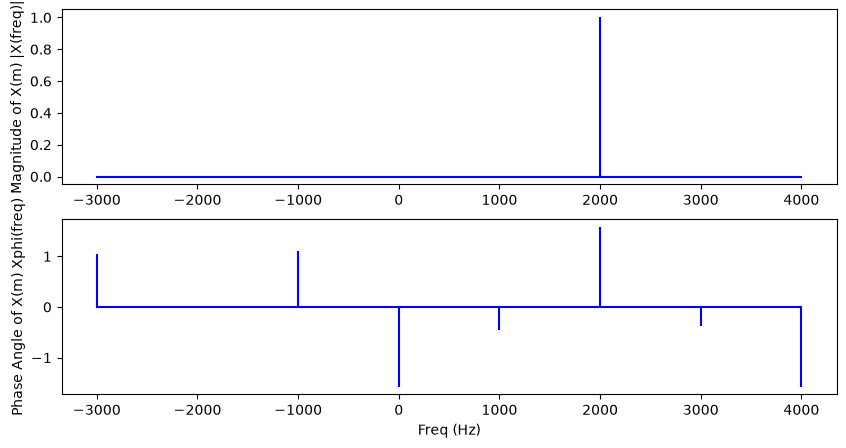

In [16]:
# Obliczenie DFT
f , X = dft ( x_t , f_s , N )

# Wyświetlenie wyników
plt.figure ( figsize = ( 10 , 5 ) )
plt.subplot ( 211 )
plt.stem ( f , np.abs(X) , 'b' ,  markerfmt = " " , basefmt = "-b" )
plt.ylabel ('Magnitude of X(m) |X(freq)|' )
plt.subplot ( 212 )
plt.stem ( f , np.angle(X) , 'b', markerfmt = " ", basefmt = "-b" )
plt.xlabel ( 'Freq (Hz)' )
plt.ylabel ( 'Phase Angle of X(m) Xphi(freq)' )
plt.show ()
